Ridership at each stop visualizations

In [36]:
import pandas as pd
import numpy as np
import os

# import the busstate files
DATA_PATH = 'K:/AP/TTM/Data/transportation-planning/data/'
BUSSTATE_PATH = DATA_PATH + 'busstate-parsed/'
PATTERN_STOPS_PATH = DATA_PATH + 'pattern-stops/'

# read the busstate files
busstate_files = [BUSSTATE_PATH + f for f in os.listdir(BUSSTATE_PATH) if f.endswith('.csv')]
busstate_dfs = [pd.read_csv(f) for f in busstate_files]

# read the pattern-stops files
pattern_stops_files = [PATTERN_STOPS_PATH + f for f in os.listdir(PATTERN_STOPS_PATH) if f.endswith('.csv')]
pattern_stops_dfs = [pd.read_csv(f) for f in pattern_stops_files]

In [37]:
# split up busstates
oct25_busstate_df = busstate_dfs[0]
feb26_busstate_df = busstate_dfs[1]

# split up pattern-stops
oct25_pattern_stops_df = pattern_stops_dfs[0]
feb26_pattern_stops_df = pattern_stops_dfs[1]

# import stop inventory
stop_inventory = pd.read_csv(DATA_PATH + 'stop_inventory.csv')

In [3]:
oct25_busstate_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1129586 entries, 0 to 1129585
Data columns (total 23 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   DATE                    1129586 non-null  str    
 1   BUS_ID                  1129586 non-null  int64  
 2   RUN_ID                  1123592 non-null  float64
 3   DEST_SIGN_ROUTE_TEXT    1129570 non-null  str    
 4   BLOCK_ID                1128291 non-null  float64
 5   TRIP_ID                 1121085 non-null  float64
 6   ROUTE_ID                1125001 non-null  str    
 7   STOP_SEQUENCE           1129586 non-null  int64  
 8   LATITUDE                1129586 non-null  float64
 9   LONGITUDE               1129586 non-null  float64
 10  HEADING                 1129586 non-null  int64  
 11  OPERATOR_ID             1112076 non-null  float64
 12  ODOMETER_DISTANCE       1129586 non-null  int64  
 13  TIMEPOINT_ID            125674 non-null   str    
 14  EVENT_TYPE   

In [38]:
# Clever Devices APC business rules that can be evaluated from the busstate files.
MAX_STOP_ACTIVITY = 90
MIN_LOAD = -5
MAX_BLOCK_DIFFERENCE = 0.30
MAX_UNKNOWN_STOP_SHARE = 0.20
MAX_LOAD_CARRYOVER = 90
STOP_MATCH_RADIUS_DEGREES = 350 / 364000

# Populate this set when the agency's APC-equipped vehicle list is available.
APC_VEHICLE_IDS = None


def _nearest_known_stop_mask(data, stop_inventory, radius=STOP_MATCH_RADIUS_DEGREES):
    """Return whether each busstate coordinate is within the configured stop radius."""
    coordinates = data[['LATITUDE', 'LONGITUDE']].to_numpy(dtype=float)
    stops = stop_inventory[['LAT', 'LONG']].to_numpy(dtype=float)
    known = np.zeros(len(data), dtype=bool)
    for start in range(0, len(data), 100_000):
        stop_slice = coordinates[start:start + 100_000]
        valid_coordinates = np.isfinite(stop_slice).all(axis=1)
        distances = np.sqrt(
            (stop_slice[:, None, 0] - stops[None, :, 0]) ** 2
            + (stop_slice[:, None, 1] - stops[None, :, 1]) ** 2
        )
        known[start:start + len(stop_slice)] = (
            valid_coordinates & (distances.min(axis=1) <= radius)
        )
    return known


def _append_reason(reasons, mask, reason):
    """Append a discard reason without replacing an earlier reason."""
    reasons.loc[mask] = reasons.loc[mask].where(
        reasons.loc[mask].eq(''),
        reasons.loc[mask] + '; ',
    ) + reason


def apply_apc_business_rules(
    data,
    stop_inventory,
    enforce_unknown_stop_rule=False,
):
    """Validate and adjust busstate records using the checked APC rules.

    The raw files do not contain a stop ID or pattern stop sequence. Therefore,
    coordinate-based unknown-stop enforcement is diagnostic by default and can
    only discard trips when explicitly enabled.
    """
    working = data.copy()
    working['DATE_PARSED'] = pd.to_datetime(working['DATE'], errors='coerce')
    working['ROUTE_ID'] = working['ROUTE_ID'].astype('string').str.strip()
    working['TRIP_KEY_VALID'] = working[
        ['DATE', 'RUN_ID', 'ROUTE_ID', 'TRIP_ID']
    ].notna().all(axis=1)
    working['RULE_REASON'] = pd.Series('', index=working.index, dtype='string')
    _append_reason(working['RULE_REASON'], working['DATE_PARSED'].isna(), 'invalid date')
    _append_reason(working['RULE_REASON'], ~working['TRIP_KEY_VALID'], 'invalid trip key')
    _append_reason(working['RULE_REASON'], working['BUS_ID'].isna(), 'null vehicle number')
    _append_reason(working['RULE_REASON'], working['BOARDINGS'].gt(MAX_STOP_ACTIVITY), 'boardings over 90')
    _append_reason(working['RULE_REASON'], working['ALIGHTINGS'].gt(MAX_STOP_ACTIVITY), 'alightings over 90')
    _append_reason(working['RULE_REASON'], working['PASSENGER_LOAD'].lt(MIN_LOAD), 'minimum load below -5')
    if APC_VEHICLE_IDS is not None:
        _append_reason(working['RULE_REASON'], ~working['BUS_ID'].isin(APC_VEHICLE_IDS), 'vehicle without APC equipment')

    # Keep this diagnostic even though enforcement is opt-in for the raw schema.
    working['KNOWN_STOP'] = _nearest_known_stop_mask(working, stop_inventory)
    trip_columns = ['DATE', 'RUN_ID', 'ROUTE_ID', 'TRIP_ID']
    trip_stats = working.groupby(trip_columns, dropna=False).agg(
        UNKNOWN_STOP_SHARE=('KNOWN_STOP', lambda values: 1 - values.mean()),
    )
    invalid_unknown_trips = trip_stats.index[trip_stats['UNKNOWN_STOP_SHARE'].gt(MAX_UNKNOWN_STOP_SHARE)]
    unknown_trip_mask = working.set_index(trip_columns).index.isin(invalid_unknown_trips)
    if enforce_unknown_stop_rule:
        _append_reason(working['RULE_REASON'], unknown_trip_mask, 'unknown activity stops over 20%')

    invalid_trip_index = working.loc[working['RULE_REASON'].ne('')].set_index(trip_columns).index
    invalid_trip_mask = working.set_index(trip_columns).index.isin(invalid_trip_index)
    _append_reason(working['RULE_REASON'], invalid_trip_mask, 'trip discarded')

    retained = working.loc[working['RULE_REASON'].eq('')].copy()
    discarded = working.loc[working['RULE_REASON'].ne('')].copy()

    block_columns = ['DATE', 'BLOCK_ID']
    block_totals = retained.groupby(block_columns, dropna=False).agg(
        BLOCK_BOARDINGS=('BOARDINGS', 'sum'),
        BLOCK_ALIGHTINGS=('ALIGHTINGS', 'sum'),
    )
    block_max = block_totals[['BLOCK_BOARDINGS', 'BLOCK_ALIGHTINGS']].max(axis=1)
    block_difference = (
        block_totals['BLOCK_BOARDINGS'] - block_totals['BLOCK_ALIGHTINGS']
    ).abs()
    invalid_blocks = block_totals.index[
        block_totals.index.get_level_values('BLOCK_ID').isna()
        | (~block_max.eq(0) & block_difference.ge(MAX_BLOCK_DIFFERENCE * block_max))
    ]
    invalid_block_mask = retained.set_index(block_columns).index.isin(invalid_blocks)
    retained.loc[invalid_block_mask, 'RULE_REASON'] = np.where(
        retained.loc[invalid_block_mask, 'BLOCK_ID'].isna(),
        'missing valid signup',
        'block boardings/alightings differ by 30% or more',
    )
    discarded = pd.concat([discarded, retained.loc[invalid_block_mask]], ignore_index=True)
    retained = retained.loc[~invalid_block_mask].copy()

    retained = retained.sort_values(
        ['BUS_ID', 'DATE_PARSED', 'BLOCK_ID', 'TRIP_ID', 'STOP_SEQUENCE', 'EVENT_TIME']
    ).copy()
    retained['RAW_BOARDINGS'] = retained['BOARDINGS']
    retained['RAW_ALIGHTINGS'] = retained['ALIGHTINGS']
    retained['RAW_PASSENGER_LOAD'] = retained['PASSENGER_LOAD']
    retained['ADJUSTED_BOARDINGS'] = retained['BOARDINGS'].astype(float)
    retained['ADJUSTED_ALIGHTINGS'] = retained['ALIGHTINGS'].astype(float)
    retained['ADJUSTED_LOAD'] = retained['PASSENGER_LOAD'].astype(float)

    for _, block in retained.groupby(block_columns, sort=False, dropna=False):
        block_index = block.index
        first_index = block_index[0]
        last_index = block_index[-1]
        retained.loc[first_index, 'ADJUSTED_ALIGHTINGS'] = 0
        retained.loc[first_index, 'ADJUSTED_LOAD'] = retained.loc[first_index, 'ADJUSTED_BOARDINGS']
        running_load = retained.loc[first_index, 'ADJUSTED_LOAD']
        for row_index in block_index[1:-1]:
            running_load += (
                retained.loc[row_index, 'ADJUSTED_BOARDINGS']
                - retained.loc[row_index, 'ADJUSTED_ALIGHTINGS']
            )
            retained.loc[row_index, 'ADJUSTED_LOAD'] = running_load
        if len(block_index) > 1:
            running_load += retained.loc[last_index, 'ADJUSTED_BOARDINGS']
            retained.loc[last_index, 'ADJUSTED_BOARDINGS'] = 0
            retained.loc[last_index, 'ADJUSTED_ALIGHTINGS'] = max(running_load, 0)
            retained.loc[last_index, 'ADJUSTED_LOAD'] = 0

    retained['LOAD_CARRYOVER'] = (
        retained.groupby(['BUS_ID', 'DATE_PARSED'])['ADJUSTED_LOAD']
        .shift(1)
        .fillna(0)
        .clip(lower=0, upper=MAX_LOAD_CARRYOVER)
    )
    retained['TRIP_KEY'] = (
        retained['DATE'].astype('string') + '|' +
        retained['RUN_ID'].astype('string') + '|' +
        retained['ROUTE_ID'] + '|' +
        retained['TRIP_ID'].astype('string')
    )
    return retained, discarded


all_busstate_df = pd.concat(busstate_dfs, ignore_index=True)
busstate_business_rules_df, discarded_busstate_df = apply_apc_business_rules(
    all_busstate_df,
    stop_inventory,
)

print(f'Input records: {len(all_busstate_df):,}')
print(f'Retained records: {len(busstate_business_rules_df):,}')
print(f'Discarded records: {len(discarded_busstate_df):,}')
print(f'Retained trips: {busstate_business_rules_df["TRIP_KEY"].nunique():,}')
print(discarded_busstate_df['RULE_REASON'].value_counts().head())

Input records: 2,126,858
Retained records: 2,068,201
Discarded records: 58,657
Retained trips: 106,596
RULE_REASON
block boardings/alightings differ by 30% or more    56372
missing valid signup                                 2285
Name: count, dtype: int64[pyarrow]


In [39]:
october_business_rules_df, october_discarded_df = apply_apc_business_rules(
    oct25_busstate_df,
    stop_inventory,
)

october_business_rules_df['BOARDINGS'].sum()

np.int64(445266)

In [40]:
october_business_rules_df['BOARDINGS'].sum()

np.int64(445266)

In [41]:
oct25_busstate_df = october_business_rules_df.copy()

OCtober 2025 total boardings per ridecheck `430,139`

In [42]:
oct25_busstate_df['BOARDINGS'].sum()

np.int64(445266)

In [43]:
oct25_busstate_df['ALIGHTINGS'].sum()

np.int64(443719)

**Boardings Comparison OCT 2025:**

Busstate: 445266

Ridecheck: 430139

Transit Lab: 438309 (Not including NWC) 


In [44]:
stop_inventory.shape

(67, 6)

In [45]:
def build_stops_df(pattern_stops_path=None, stop_inventory_df=None, verbose=True):
    '''
    Build stops dataframe by merging static pattern stops and stop inventory files. Anytime that stops change, this will need to be re run after the csv files are updated.
    This contains every stop for CABS.

    Parameters:
        pattern_stops_path (str | None): path to the pattern-stops csv for the desired schedule period.
            Defaults to the October 2025 pattern-stops file when not provided.
        stop_inventory_df (pd.DataFrame | None): stop inventory dataframe to merge against.
            Defaults to the global `stop_inventory` variable when not provided.
        verbose (bool): print shape diagnostics while building. Set False for quiet, looped runs.
    Returns:
        stops_df (pd.DataFrame): dataframe with stop id, stop name, and lat/lon coordinates for all stops in the pattern stops file
    '''
    if pattern_stops_path is None:
        pattern_stops_path = f"{PATTERN_STOPS_PATH}2025082420251018Sch-PatternStops_oct2025.csv"
    if stop_inventory_df is None:
        stop_inventory_df = stop_inventory

    # read in static stop files
    pattern_stops = pd.read_csv(pattern_stops_path, header = None) # no header

    if verbose:
        print(pattern_stops.shape)
        print(stop_inventory_df.shape)

    # only need cols 0 and 9 and can drop any dups
    pattern_stops = pattern_stops.iloc[:, [0, 9]].drop_duplicates()
    pattern_stops.columns = ["ROUTE", "STOP_ID"] # rename cols for merge

    # Merge pattern stops and stop inventory on stop id - left merge 
    stops_df = pattern_stops.merge(stop_inventory_df, how = "left", on = "STOP_ID")

    if verbose:
        print(stops_df.shape)

    return stops_df


In [46]:
stops_df = build_stops_df()
print(stops_df.shape)
stops_df.head()

(230, 46)
(67, 6)
(96, 7)
(96, 7)


,ROUTE,STOP_ID,STOP_NAME,TIMEPOINT_NAME,LONG,LAT,HEADING
0,BE,75,BUCKEYE LOT LOOP,BLOOP,-83.030646,40.015933,180.0
1,BE,20,MID WEST CAMPUS (EB),AGEB,-83.026541,40.004251,90.0
2,BE,21,ST. JOHN EAST BOUND,NaN,-83.020744,40.004048,90.0
3,BE,57,KNOWLTON HALL,KNWTN,-83.016142,40.003979,90.0
4,BE,58,FONTANA LAB,NaN,-83.013197,40.003839,90.0


In [13]:
stops_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ROUTE           96 non-null     str    
 1   STOP_ID         96 non-null     int64  
 2   STOP_NAME       96 non-null     str    
 3   TIMEPOINT_NAME  48 non-null     str    
 4   LONG            96 non-null     float64
 5   LAT             96 non-null     float64
 6   HEADING         88 non-null     float64
dtypes: float64(3), int64(1), str(3)
memory usage: 7.3 KB


In [47]:
# removing the route parameter, for this analysis, only boardings and alightings matter, overlapping stops on different routes should not impact the results here
def which_stop(lat, lon, stops_df = None, max_distance = 0.0005):
    '''s
    Determine the closest stop to a given latitude and longitude. Med center route is default, but can be updated to other routes as needed. 
    NOTE: if stops_df is not provided, falls back to a global `stops_df` variable, which must exist (created via build_stops_df()).

    Args:
        lat (float): The latitude of the point of interest.
        lon (float): The longitude of the point of interest.
        stops_df (pd.DataFrame | None): DataFrame containing stop information created from build_stops_df() function.
            Falls back to the global `stops_df` variable when not provided.
        max_distance (float): The maximum distance to consider for a stop. Default is 0.0005 per legacy R code. approximately 150ish feet

    Returns:
        int: The STOP_ID of the closest stop within approximately 150 feet, or None if no stops are within the specified distance.
    '''
    if stops_df is None:
        stops_df = globals().get('stops_df')
        if stops_df is None:
            raise ValueError('stops_df must be provided or defined as a global variable (see build_stops_df()).')

    distance_lon = stops_df['LONG'].values - lon
    distance_lat = stops_df['LAT'].values - lat

    # calculate the distance to each stop
    distances = np.sqrt(distance_lon**2 + distance_lat**2)

    mask = distances < max_distance
    # lowest distance should be the closest stop now. - each stop is at minimum approx 430ft apart so margin of 150 should be fine for MC route.
    selected_stop = stops_df[mask]

    # if no stops within alloted distance, return None
    if not np.any(mask):
        return None

    # return the closest stop within the allotted distance
    return int(stops_df.loc[mask, 'STOP_ID'].iloc[0])


In [48]:
# filter and run the which_stop function for a given set of coordinates on the october data
filtered_oct_df = oct25_busstate_df.copy()  # assuming october_data is the DataFrame containing the October data
# sort by date and event time
filtered_oct_df = filtered_oct_df.sort_values(by=['DATE', 'EVENT_TIME'])
# apply the which_stop function to each row to determine the closest stop
filtered_oct_df['STOP_ID'] = filtered_oct_df.apply(lambda row: which_stop(row['LATITUDE'], row['LONGITUDE']), axis=1)

In [16]:
filtered_oct_df.describe().T

,count,mean,min,25%,50%,75%,max,std
BUS_ID,1107781.0,2026.047642,1301.0,1801.0,2003.0,2302.0,2503.0,341.558491
RUN_ID,1104304.0,1391.437387,1001.0,1301.0,1405.0,1504.0,7000.0,315.850897
BLOCK_ID,1107781.0,23676264.46413,23672305.0,23675302.0,23676502.0,23677202.0,23684201.0,1493.095056
TRIP_ID,1102555.0,1971575.956607,1020.0,942020.0,1959050.0,2970020.0,4141051.0,1179495.24548
STOP_SEQUENCE,1107781.0,3.515823,-1.0,1.0,3.0,5.0,16.0,3.587117
LATITUDE,1107781.0,40.001936,0.0,39.997997,40.001812,40.004055,40.017254,0.076176
LONGITUDE,1107781.0,-83.022585,-83.04348,-83.033363,-83.024529,-83.013252,0.0,0.158326
HEADING,1107781.0,182.924016,0.0,92.0,182.0,274.0,360.0,111.989703
OPERATOR_ID,1095258.0,781.997577,7.0,739.0,761.0,786.0,7310.0,256.01578
ODOMETER_DISTANCE,1107781.0,329784.922066,0.0,128854.0,290556.0,501275.0,1279225.0,232919.124659


In [49]:
# left merge the names of the stops with the filtered October DataFrame
filtered_oct_df = filtered_oct_df.merge(stops_df[['STOP_ID', 'STOP_NAME']], on='STOP_ID', how='left')

In [18]:
filtered_oct_df['STOP_NAME'].value_counts()

STOP_NAME
JOHN HERRICK LOOP       316036
OHIO UNION (NB)         146632
MID WEST CAMPUS (EB)     91440
ARPS HALL                71504
MOUNT HALL LOOP          57507
                         ...  
MID WEST CAMPUS (WB)       776
ST. JOHN ARENA (WB)        393
11TH & WORTHINGTON         302
STOP3                      294
OHIO UNION (SB)            171
Name: count, Length: 61, dtype: int64

In [19]:
service_annex_testcase = filtered_oct_df[filtered_oct_df['STOP_ID'] == 103]
print(f'Boardings at Service Annex: {service_annex_testcase["BOARDINGS"].describe().T}')
print(f'Alightings at Service Annex: {service_annex_testcase["ALIGHTINGS"].describe().T}')

Boardings at Service Annex: count    2723.000000
mean        0.130738
std         0.419692
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         3.000000
Name: BOARDINGS, dtype: float64
Alightings at Service Annex: count    2723.000000
mean        0.154976
std         0.494124
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         5.000000
Name: ALIGHTINGS, dtype: float64


In [50]:
# convert to dateimte
filtered_oct_df['EVENT_TIME'] = pd.to_datetime(filtered_oct_df['EVENT_TIME'], format = "%H:%M:%S")
filtered_oct_df['DEPARTURE_TIME'] = pd.to_datetime(filtered_oct_df['DEPARTURE_TIME'], format = "%H:%M:%S")
filtered_oct_df['ENTER_STOP_WINDOW_TIME'] = pd.to_datetime(filtered_oct_df['ENTER_STOP_WINDOW_TIME'], format = "%H:%M:%S")
filtered_oct_df['EXIT_STOP_WINDOW_TIME'] = pd.to_datetime(filtered_oct_df['EXIT_STOP_WINDOW_TIME'], format = "%H:%M:%S")

In [51]:
count = (
    (filtered_oct_df['STOP_ID'] != filtered_oct_df['STOP_ID'].shift(1)) |
    (filtered_oct_df['BUS_ID'] != filtered_oct_df['BUS_ID'].shift(1)) |
    ((filtered_oct_df['EVENT_TIME'] - filtered_oct_df['EVENT_TIME'].shift(1)).dt.total_seconds() >= 3600) 
    # this should create a new event if more than an hour has passed since the last event
)

# take cumsum of count to assign 
filtered_oct_df['COUNT'] = count.cumsum()

# consolidate df
consolidated_busstate_df = filtered_oct_df.groupby(['BUS_ID', 'DATE', 'COUNT', 'STOP_ID', 'STOP_NAME', 'RUN_ID'], as_index = False).agg(
    BOARDINGS = ('BOARDINGS', 'max'), # this WAS max
    ALIGHTINGS = ('ALIGHTINGS', 'max'), # this WAS max
    LOAD = ('PASSENGER_LOAD', 'max'),
    EARLY_EVENT=("EVENT_TIME", "min"),
    LATE_EVENT=("EVENT_TIME", "max"),
    DEPARTURE_TIME=("DEPARTURE_TIME", "max"),
    ENTER_STOP=("ENTER_STOP_WINDOW_TIME", "min"),
    EXIT_STOP=("EXIT_STOP_WINDOW_TIME", "max"),
    RUN_ID = ("RUN_ID", "last"),
    STOP_NAME = ("STOP_NAME", "last"),
    DEST=("DEST_SIGN_ROUTE_TEXT", "last"),
)

print(consolidated_busstate_df.shape)
consolidated_busstate_df.head()

(411556, 15)


,BUS_ID,DATE,COUNT,STOP_ID,BOARDINGS,ALIGHTINGS,LOAD,EARLY_EVENT,LATE_EVENT,DEPARTURE_TIME,ENTER_STOP,EXIT_STOP,RUN_ID,STOP_NAME,DEST
0,1301,2025-10-02,43123,403.0,10,0,10,1900-01-01 06:06:41,1900-01-01 06:06:41,1900-01-01 06:07:20,1900-01-01 06:03:46,1900-01-01 06:07:32,1509.0,CARMACK 2,MC
1,1301,2025-10-02,43175,404.0,4,0,14,1900-01-01 06:08:48,1900-01-01 06:08:48,1900-01-01 06:09:16,1900-01-01 06:08:38,1900-01-01 06:09:28,1509.0,CARMACK 3,MC
2,1301,2025-10-02,43227,502.0,0,0,0,1900-01-01 06:10:51,1900-01-01 06:10:51,NaT,NaT,NaT,1509.0,(FS) PS (IN),MC
3,1301,2025-10-02,43360,405.0,0,0,0,1900-01-01 06:15:05,1900-01-01 06:15:05,1900-01-01 06:15:22,NaT,NaT,1509.0,JOHN HERRICK LOOP,MC
4,1301,2025-10-02,43365,405.0,0,14,0,1900-01-01 06:15:16,1900-01-01 06:15:16,1900-01-01 06:15:16,1900-01-01 06:15:11,1900-01-01 06:15:21,1509.0,JOHN HERRICK LOOP,MC


In [22]:
consolidated_busstate_df['STOP_NAME'].value_counts()

STOP_NAME
JOHN HERRICK LOOP       47442
CARMACK 2               29938
OHIO UNION (NB)         23794
MID WEST CAMPUS (EB)    21558
(FS) PS (OB)            18088
                        ...  
STOP3                     290
MID WEST CAMPUS (WB)      183
11TH & WORTHINGTON        151
ST. JOHN ARENA (WB)       131
OHIO UNION (SB)           104
Name: count, Length: 61, dtype: int64

In [23]:
# create summary statistics for boardings/alightings at each stop
stop_summary_stats = consolidated_busstate_df.groupby('STOP_NAME', as_index=False).agg(
    # BOARDINGS_MEAN=('BOARDINGS', 'mean'),
    BOARDINGS_SUM=('BOARDINGS', 'sum'),
    # ALIGHTINGS_MEAN=('ALIGHTINGS', 'mean'),
    ALIGHTINGS_SUM=('ALIGHTINGS', 'sum'),
)
# msort by total bordings
stop_summary_stats = stop_summary_stats.sort_values(by='BOARDINGS_SUM', ascending=False)

stop_summary_stats.head(50)

,STOP_NAME,BOARDINGS_SUM,ALIGHTINGS_SUM
31,JOHN HERRICK LOOP,83151,85407
39,OHIO UNION (NB),51184,33924
16,BUCKEYE LOT LOOP,26130,25553
19,CARMACK 3,24942,22781
18,CARMACK 2,23993,27134
36,MID WEST CAMPUS (EB),23520,24905
24,FONTANA LAB,23071,22764
35,MASON HALL,22583,16086
14,BLACKBURN HOUSE,22190,18975
20,CARMACK 5 + STOP 1,21612,23823


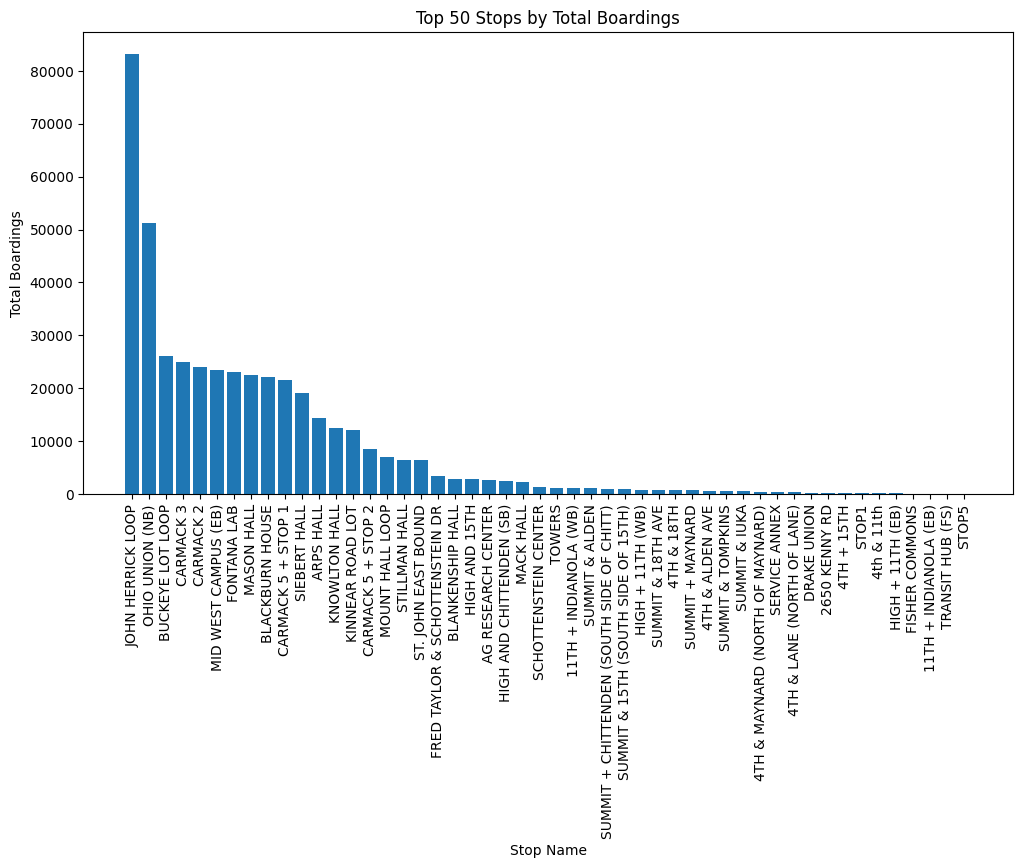

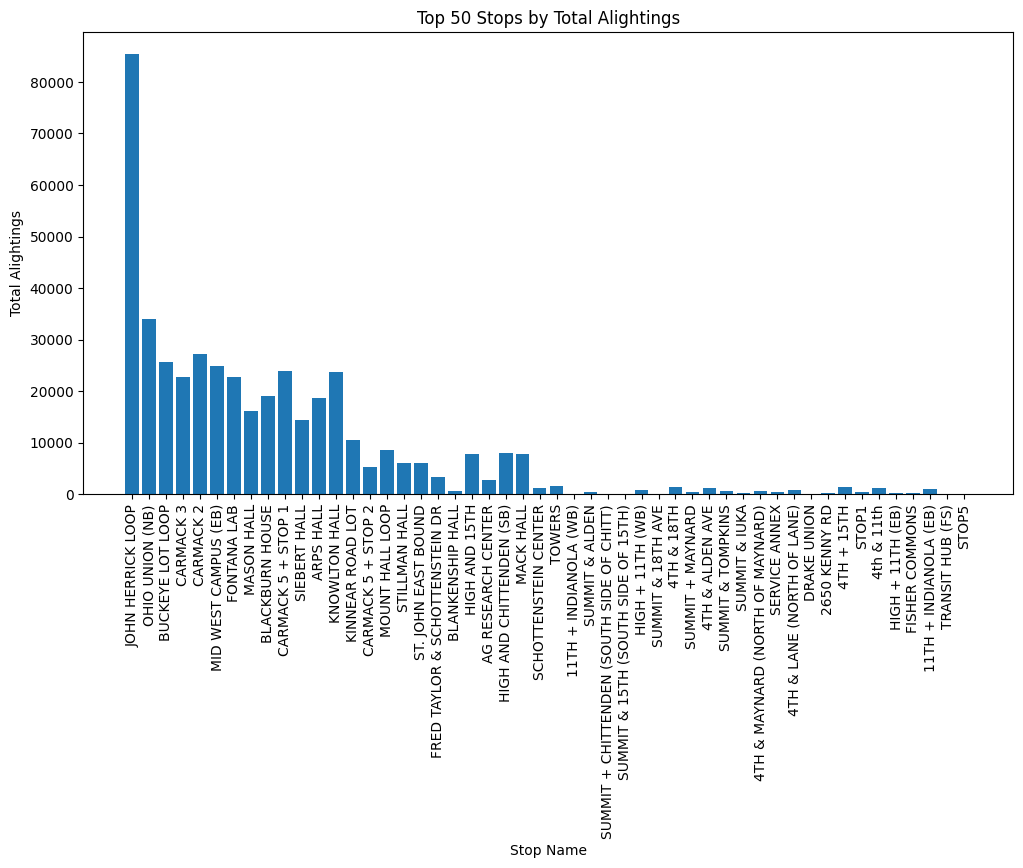

In [24]:
# plot top 50 stops by boardings
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
ax = plt.bar(stop_summary_stats['STOP_NAME'].head(50), stop_summary_stats['BOARDINGS_SUM'].head(50))

plt.xticks(rotation=90)
plt.xlabel('Stop Name')
plt.ylabel('Total Boardings')
plt.title('Top 50 Stops by Total Boardings')
plt.show()

# plot top 50 stops by alightings
plt.figure(figsize=(12, 6))
plt.bar(stop_summary_stats['STOP_NAME'].head(50), stop_summary_stats['ALIGHTINGS_SUM'].head(50))
plt.xticks(rotation=90)
plt.xlabel('Stop Name')
plt.ylabel('Total Alightings')
plt.title('Top 50 Stops by Total Alightings')
plt.show()

In [33]:
consolidated_busstate_df['RUN_ID'].unique()

array([1509., 1502., 1508., 1511., 1503., 1512., 7000., 1501., 1513.,
       1301., 1505., 1302., 1506., 1504., 1001., 1432., 1403., 1401.,
       1201., 1331., 1003., 1507., 1514., 2601., 1451., 1402., 1452.,
       1404., 1405., 2201., 1002., 1431., 2101., 1433., 1031., 1032.,
       1510., 1004., 1202., 1601., 1631., 1231., 1232.])

In [52]:
# remove MC routes to avoid the skewing here...
med_center_run_ids = [
    1501,
    1502,
    1503,
    1504,
    1505,
    1506,
    1507,
    1508,
    1509,
    1510,
    1511,
    1512,
    1513,
    1514,
]

football_shuttle_id = 2101

schott_shuttle_id = 2201

cut_consolidated_busstate_df = consolidated_busstate_df[~consolidated_busstate_df['RUN_ID'].isin(med_center_run_ids + [football_shuttle_id, schott_shuttle_id])]


# recalculate stop summary stats after removing MC routes
stop_summary_stats = cut_consolidated_busstate_df.groupby('STOP_NAME', as_index=False).agg(
    BOARDINGS_SUM=('BOARDINGS', 'sum'),
    ALIGHTINGS_SUM=('ALIGHTINGS', 'sum'),
)
stop_summary_stats = stop_summary_stats.sort_values(by='BOARDINGS_SUM', ascending=False)
stop_summary_stats

,STOP_NAME,BOARDINGS_SUM,ALIGHTINGS_SUM
39,OHIO UNION (NB),51184,33924
16,BUCKEYE LOT LOOP,24913,24040
36,MID WEST CAMPUS (EB),23520,24905
24,FONTANA LAB,23071,22764
35,MASON HALL,22583,16086
...,...,...,...
30,IN BOUND,0,3
41,Outbound to Carmack,0,0
45,ST. JOHN ARENA (WB),0,0
49,STOP3,0,0


In [26]:
stop_summary_stats[stop_summary_stats['STOP_NAME'].str.contains('OHIO UNION')]

,STOP_NAME,BOARDINGS_SUM,ALIGHTINGS_SUM
39,OHIO UNION (NB),51184,33924
40,OHIO UNION (SB),0,0


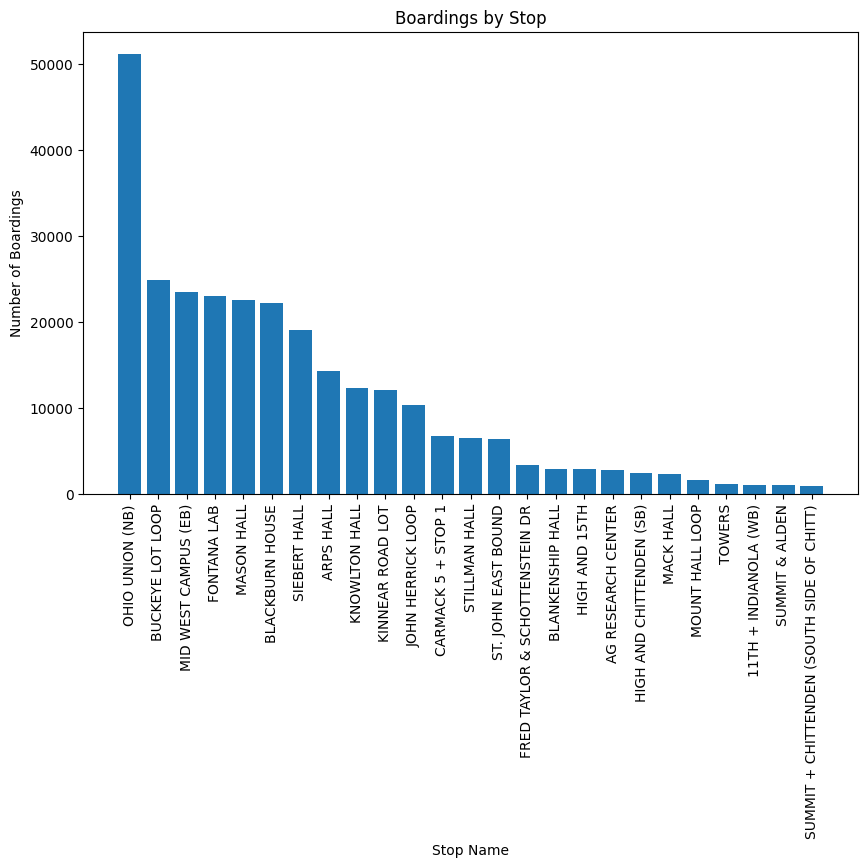

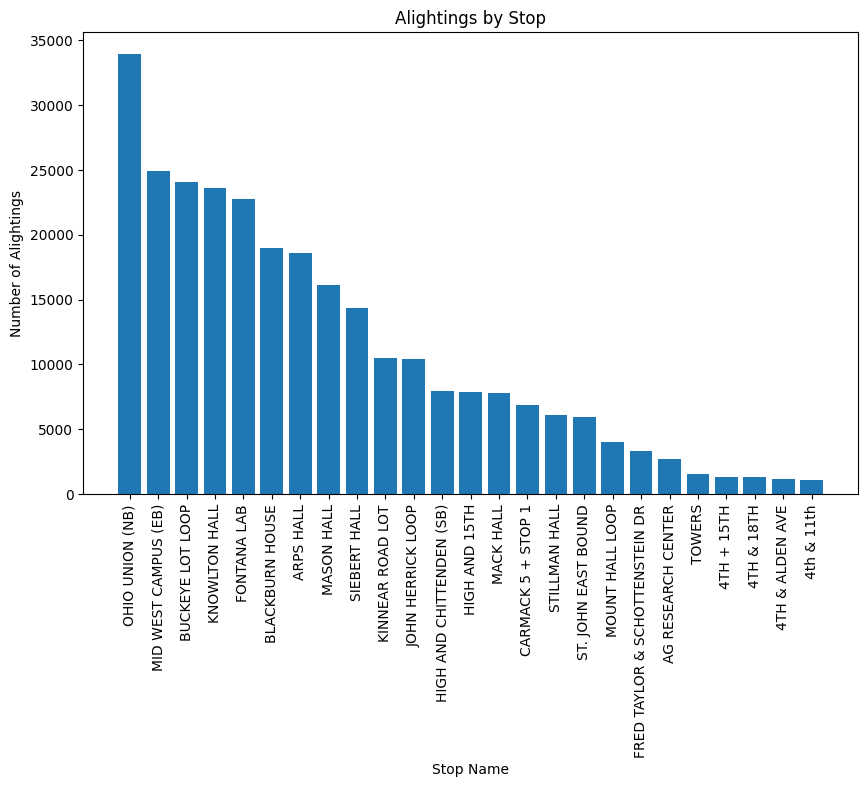

In [27]:
# plot the boardings 
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.bar(stop_summary_stats['STOP_NAME'].head(25), stop_summary_stats['BOARDINGS_SUM'].head(25))
plt.xticks(rotation=90)
plt.xlabel('Stop Name')
plt.ylabel('Number of Boardings')
plt.title('Boardings by Stop')
plt.show()

alightings_stop_summary_stats = stop_summary_stats.sort_values(by='ALIGHTINGS_SUM', ascending=False)
# alightings
plt.figure(figsize=(10,6))
plt.bar(alightings_stop_summary_stats['STOP_NAME'].head(25), alightings_stop_summary_stats['ALIGHTINGS_SUM'].head(25))
plt.xticks(rotation=90)
plt.xlabel('Stop Name')
plt.ylabel('Number of Alightings')
plt.title('Alightings by Stop')
plt.show()

In [32]:
# Interactive geographic heatmap of October boardings by stop.
import folium
from branca.colormap import linear

stop_boarding_map = (
    consolidated_busstate_df
    .groupby('STOP_ID', as_index=False)
    .agg(BOARDINGS_SUM=('BOARDINGS', 'sum'))
    .merge(
        stop_inventory[['STOP_ID', 'STOP_NAME', 'LONG', 'LAT']],
        on='STOP_ID',
        how='left',
        validate='one_to_one',
    )
    .dropna(subset=['LONG', 'LAT'])
)

plot_data = stop_boarding_map.loc[
    stop_boarding_map['BOARDINGS_SUM'].gt(0)
].copy()

map_center = [plot_data['LAT'].mean(), plot_data['LONG'].mean()]
boarding_min = plot_data['BOARDINGS_SUM'].min()
boarding_max = plot_data['BOARDINGS_SUM'].max()
color_scale = linear.YlOrRd_09.scale(boarding_min, boarding_max)
color_scale.caption = 'Total October boardings'

boarding_map = folium.Map(
    location=map_center,
    zoom_start=13,
    tiles='OpenStreetMap',
    control_scale=True,
)

for _, stop in plot_data.iterrows():
    boarding_count = int(stop['BOARDINGS_SUM'])
    radius = 5 + 14 * (boarding_count / boarding_max) ** 0.5
    popup_html = (
        f"<strong>{stop['STOP_NAME']}</strong><br>"
        f"Stop ID: {int(stop['STOP_ID'])}<br>"
        f"Boardings: {boarding_count:,}"
    )
    folium.CircleMarker(
        location=[stop['LAT'], stop['LONG']],
        radius=radius,
        color='#7f0000',
        weight=1,
        fill=True,
        fill_color=color_scale(boarding_count),
        fill_opacity=0.8,
        tooltip=f"{stop['STOP_NAME']}: {boarding_count:,} boardings",
        popup=folium.Popup(popup_html, max_width=250),
    ).add_to(boarding_map)

color_scale.add_to(boarding_map)
boarding_map.save('boarding_map.html')

## **Known Problem**

It appears that the 2 Ohio Union stops as well as the 2 Midwest campus stops are too geographically close to one another to differentiate them currently.

## Reusable Multi-Month Visualization Pipeline

The functions below turn a raw busstate dataframe into stop-level summary statistics and a
standard set of visualizations (bar charts + a multi-layer folium map). They are written so a
single `process_month()` call handles one month end-to-end, and can be looped over any number
of months to batch-produce visualizations for transit planning.


In [53]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import folium
from folium.plugins import HeatMap
from branca.colormap import linear


def _slugify(label):
    '''Turn a human readable month label (e.g. "October 2025") into a filename-safe slug.'''
    return re.sub(r'[^a-z0-9]+', '_', label.lower()).strip('_')


In [54]:
def assign_stop_ids(busstate_df, stops_df, max_distance=STOP_MATCH_RADIUS_DEGREES):
    '''
    Sort a busstate dataframe by date/time and attach the nearest stop id + name to each record.

    Args:
        busstate_df (pd.DataFrame): busstate records (after business rules) with LATITUDE/LONGITUDE columns.
        stops_df (pd.DataFrame): stops reference dataframe from build_stops_df().
        max_distance (float): max distance (degrees) to match a coordinate to a stop.

    Returns:
        pd.DataFrame: busstate_df sorted by DATE/EVENT_TIME with STOP_ID and STOP_NAME columns attached.
    '''
    assigned = busstate_df.sort_values(by=['DATE', 'EVENT_TIME']).copy()
    assigned['STOP_ID'] = assigned.apply(
        lambda row: which_stop(row['LATITUDE'], row['LONGITUDE'], stops_df=stops_df, max_distance=max_distance),
        axis=1,
    )
    assigned = assigned.merge(
        stops_df[['STOP_ID', 'STOP_NAME']].drop_duplicates(subset='STOP_ID'),
        on='STOP_ID',
        how='left',
    )
    return assigned


In [55]:
def consolidate_events(assigned_df, gap_seconds=3600):
    '''
    Collapse repeated APC pings for the same stop visit into a single consolidated event row.

    A new event starts whenever the stop, bus, or elapsed time (>= gap_seconds) changes.

    Args:
        assigned_df (pd.DataFrame): busstate records with STOP_ID/STOP_NAME attached (see assign_stop_ids()).
        gap_seconds (int): minimum elapsed seconds between pings for them to be treated as separate events.

    Returns:
        pd.DataFrame: one row per consolidated stop event, with BOARDINGS/ALIGHTINGS/LOAD summarized.
    '''
    df = assigned_df.copy()

    time_cols = ['EVENT_TIME', 'DEPARTURE_TIME', 'ENTER_STOP_WINDOW_TIME', 'EXIT_STOP_WINDOW_TIME']
    for col in time_cols:
        if not pd.api.types.is_datetime64_any_dtype(df[col]):
            df[col] = pd.to_datetime(df[col], format='%H:%M:%S')

    is_new_event = (
        (df['STOP_ID'] != df['STOP_ID'].shift(1)) |
        (df['BUS_ID'] != df['BUS_ID'].shift(1)) |
        ((df['EVENT_TIME'] - df['EVENT_TIME'].shift(1)).dt.total_seconds() >= gap_seconds)
    )
    df['COUNT'] = is_new_event.cumsum()

    consolidated = df.groupby(
        ['BUS_ID', 'DATE', 'COUNT', 'STOP_ID', 'STOP_NAME', 'RUN_ID'], as_index=False
    ).agg(
        BOARDINGS=('BOARDINGS', 'max'),
        ALIGHTINGS=('ALIGHTINGS', 'max'),
        LOAD=('PASSENGER_LOAD', 'max'),
        EARLY_EVENT=('EVENT_TIME', 'min'),
        LATE_EVENT=('EVENT_TIME', 'max'),
        DEPARTURE_TIME=('DEPARTURE_TIME', 'max'),
        ENTER_STOP=('ENTER_STOP_WINDOW_TIME', 'min'),
        EXIT_STOP=('EXIT_STOP_WINDOW_TIME', 'max'),
        DEST=('DEST_SIGN_ROUTE_TEXT', 'last'),
    )
    return consolidated


In [56]:
def build_stop_summary(consolidated_df, stop_inventory_df, exclude_run_ids=None):
    '''
    Aggregate consolidated stop events into per-stop summary statistics with coordinates attached.

    Args:
        consolidated_df (pd.DataFrame): output of consolidate_events().
        stop_inventory_df (pd.DataFrame): stop inventory with STOP_ID/LAT/LONG columns.
        exclude_run_ids (list | None): RUN_IDs to drop before summarizing (e.g. shuttle routes that skew totals).

    Returns:
        pd.DataFrame: one row per stop with BOARDINGS_SUM, ALIGHTINGS_SUM, NET_FLOW, AVG_LOAD, EVENTS, LAT, LONG.
    '''
    df = consolidated_df
    if exclude_run_ids:
        df = df[~df['RUN_ID'].isin(exclude_run_ids)]

    summary = df.groupby(['STOP_ID', 'STOP_NAME'], as_index=False).agg(
        BOARDINGS_SUM=('BOARDINGS', 'sum'),
        ALIGHTINGS_SUM=('ALIGHTINGS', 'sum'),
        AVG_LOAD=('LOAD', 'mean'),
        EVENTS=('BUS_ID', 'count'),
    )
    summary['NET_FLOW'] = summary['BOARDINGS_SUM'] - summary['ALIGHTINGS_SUM']

    summary = summary.merge(
        stop_inventory_df[['STOP_ID', 'LAT', 'LONG']],
        on='STOP_ID',
        how='left',
    )
    return summary.sort_values('BOARDINGS_SUM', ascending=False).reset_index(drop=True)


In [57]:
def plot_top_stops(summary_df, label, metric='BOARDINGS_SUM', top_n=25, save_path=None, color='#d94801'):
    '''Bar chart of the top N stops for a given metric (e.g. BOARDINGS_SUM or ALIGHTINGS_SUM).'''
    top_stops = summary_df.sort_values(metric, ascending=False).head(top_n)
    metric_label = metric.replace('_SUM', '').title()

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.bar(top_stops['STOP_NAME'], top_stops[metric], color=color)
    ax.set_xticks(range(len(top_stops)))
    ax.set_xticklabels(top_stops['STOP_NAME'], rotation=90)
    ax.set_xlabel('Stop Name')
    ax.set_ylabel(f'Total {metric_label}')
    ax.set_title(f'{label}: Top {top_n} Stops by {metric_label}')
    fig.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=150)
    plt.show()
    plt.close(fig)
    return fig


def plot_boardings_vs_alightings(summary_df, label, top_n=20, save_path=None):
    '''Grouped bar chart comparing boardings vs alightings for the busiest stops.'''
    top_stops = summary_df.sort_values('BOARDINGS_SUM', ascending=False).head(top_n)
    x = np.arange(len(top_stops))
    width = 0.4

    fig, ax = plt.subplots(figsize=(13, 6))
    ax.bar(x - width / 2, top_stops['BOARDINGS_SUM'], width, label='Boardings', color='#d94801')
    ax.bar(x + width / 2, top_stops['ALIGHTINGS_SUM'], width, label='Alightings', color='#2171b5')
    ax.set_xticks(x)
    ax.set_xticklabels(top_stops['STOP_NAME'], rotation=90)
    ax.set_ylabel('Total Count')
    ax.set_title(f'{label}: Boardings vs Alightings (Top {top_n} Stops)')
    ax.legend()
    fig.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=150)
    plt.show()
    plt.close(fig)
    return fig


In [66]:
def build_boarding_folium_map(summary_df, label, save_path=None):
    '''
    Build a multi-layer interactive folium map for a month of stop-level ridership.
     Uses plain OpenStreetMap tiles, which are free and require no API key.

    Layers (toggleable via LayerControl):
      - Boardings: circle markers sized/colored by total boardings
      - Alightings: circle markers sized/colored by total alightings
      - Boardings Heatmap: heat intensity scaled by each stop's boarding magnitude

    Args:
        summary_df (pd.DataFrame): output of build_stop_summary(), must include LAT/LONG.
        label (str): human readable label for the month/period (used in titles + legend).
        save_path (str | Path | None): if provided, saves the map to this HTML path.

    Returns:
        folium.Map
    '''
    plot_data = summary_df.dropna(subset=['LAT', 'LONG']).copy()
    plot_data = plot_data[(plot_data['BOARDINGS_SUM'] > 0) | (plot_data['ALIGHTINGS_SUM'] > 0)]

    if plot_data.empty:
        raise ValueError(f'No stops with boarding/alighting activity found for {label}')

    map_center = [plot_data['LAT'].mean(), plot_data['LONG'].mean()]
    fmap = folium.Map(location=map_center, zoom_start=13, tiles='OpenStreetMap', control_scale=True)

    title_html = f'''
        <h3 style="position:fixed; top:10px; left:60px; z-index:9999; background:white;
        padding:6px 12px; border-radius:4px; box-shadow:0 0 5px rgba(0,0,0,0.3);
        font-family:sans-serif;">{label} Transit Boardings &amp; Alightings</h3>
    '''
    fmap.get_root().html.add_child(folium.Element(title_html))

    boarding_max = plot_data['BOARDINGS_SUM'].max()
    alighting_max = plot_data['ALIGHTINGS_SUM'].max()

    boarding_scale = linear.YlOrRd_09.scale(plot_data['BOARDINGS_SUM'].min(), boarding_max)
    alighting_scale = linear.YlGnBu_09.scale(plot_data['ALIGHTINGS_SUM'].min(), alighting_max)

    boardings_layer = folium.FeatureGroup(name='Boardings', show=True)
    alightings_layer = folium.FeatureGroup(name='Alightings', show=False)
    heatmap_layer = folium.FeatureGroup(name='Boardings Heatmap', show=False)

    for _, stop in plot_data.iterrows():
        boardings = int(stop['BOARDINGS_SUM'])
        alightings = int(stop['ALIGHTINGS_SUM'])
        popup_html = (
            f"<strong>{stop['STOP_NAME']}</strong><br>"
            f"Stop ID: {int(stop['STOP_ID'])}<br>"
            f"Boardings: {boardings:,}<br>"
            f"Alightings: {alightings:,}"
        )

        boardings_radius = 5 + 14 * (boardings / boarding_max) ** 0.5 if boarding_max else 5
        folium.CircleMarker(
            location=[stop['LAT'], stop['LONG']],
            radius=boardings_radius,
            color='#7f0000',
            weight=1,
            fill=True,
            fill_color=boarding_scale(boardings),
            fill_opacity=0.8,
            tooltip=f"{stop['STOP_NAME']}: {boardings:,} boardings",
            popup=folium.Popup(popup_html, max_width=260),
        ).add_to(boardings_layer)

        alightings_radius = 5 + 14 * (alightings / alighting_max) ** 0.5 if alighting_max else 5
        folium.CircleMarker(
            location=[stop['LAT'], stop['LONG']],
            radius=alightings_radius,
            color='#08306b',
            weight=1,
            fill=True,
            fill_color=alighting_scale(alightings),
            fill_opacity=0.8,
            tooltip=f"{stop['STOP_NAME']}: {alightings:,} alightings",
            popup=folium.Popup(popup_html, max_width=260),
        ).add_to(alightings_layer)

    # Normalize weight per stop (0-1) so heat intensity reflects each stop's own boarding
    # magnitude rather than how many nearby stops happen to overlap in a given area.
    heat_data = [
        [row['LAT'], row['LONG'], row['BOARDINGS_SUM'] / boarding_max]
        for _, row in plot_data.iterrows()
    ]
    HeatMap(
        heat_data,
        radius=16,
        blur=10,
        min_opacity=0.25,
    ).add_to(heatmap_layer)

    boardings_layer.add_to(fmap)
    alightings_layer.add_to(fmap)
    heatmap_layer.add_to(fmap)

    boarding_scale.caption = f'{label} total boardings'
    boarding_scale.add_to(fmap)

    folium.LayerControl(collapsed=False).add_to(fmap)

    if save_path:
        fmap.save(str(save_path))

    return fmap


In [64]:
def generate_month_visualizations(summary_df, label, output_dir='visualizations', top_n=25):
    '''
    Generate and save the standard set of visualizations for one month's stop summary.

    Args:
        summary_df (pd.DataFrame): output of build_stop_summary().
        label (str): human readable label for the month/period (e.g. "October 2025").
        output_dir (str | Path): directory where png/html outputs are saved (created if missing).
        top_n (int): number of stops shown in the bar charts.

    Returns:
        dict[str, Path]: paths to the generated files, keyed by visualization name.
    '''
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    slug = _slugify(label)

    paths = {}

    paths['boardings_bar'] = output_dir / f'{slug}_top_boardings.png'
    plot_top_stops(summary_df, label, metric='BOARDINGS_SUM', top_n=top_n, save_path=paths['boardings_bar'], color='#d94801')

    paths['alightings_bar'] = output_dir / f'{slug}_top_alightings.png'
    plot_top_stops(summary_df, label, metric='ALIGHTINGS_SUM', top_n=top_n, save_path=paths['alightings_bar'], color='#2171b5')

    paths['comparison_bar'] = output_dir / f'{slug}_boardings_vs_alightings.png'
    plot_boardings_vs_alightings(summary_df, label, top_n=min(top_n, 20), save_path=paths['comparison_bar'])

    paths['map'] = output_dir / f'{slug}_boarding_map.html'
    build_boarding_folium_map(summary_df, label, save_path=paths['map'])

    print(f'{label}: saved {len(paths)} visualizations to {output_dir.resolve()}')
    return paths


In [60]:
def process_month(
    label,
    raw_busstate_df,
    pattern_stops_path,
    stop_inventory_df,
    exclude_run_ids=None,
    output_dir='visualizations',
    top_n=25,
    gap_seconds=3600,
):
    '''
    End-to-end pipeline for a single month of busstate data: business rules -> stop matching ->
    event consolidation -> stop summary -> saved visualizations.

    Args:
        label (str): human readable label for the month/period (e.g. "October 2025").
        raw_busstate_df (pd.DataFrame): unprocessed busstate records for the month.
        pattern_stops_path (str): path to the pattern-stops csv covering this month's schedule.
        stop_inventory_df (pd.DataFrame): stop inventory with STOP_ID/LAT/LONG columns.
        exclude_run_ids (list | None): RUN_IDs to exclude from the stop summary (e.g. shuttle routes).
        output_dir (str | Path): directory where visualizations are saved.
        top_n (int): number of stops shown in the bar charts.
        gap_seconds (int): elapsed seconds threshold used to split consolidated events.

    Returns:
        dict: {
            'business_rules_df', 'discarded_df', 'consolidated_df', 'summary_df', 'visualizations'
        }
    '''
    print(f'--- Processing {label} ---')
    business_rules_df, discarded_df = apply_apc_business_rules(raw_busstate_df, stop_inventory_df)
    print(f'{label}: retained {len(business_rules_df):,} of {len(raw_busstate_df):,} records')

    stops_df = build_stops_df(pattern_stops_path, stop_inventory_df, verbose=False)
    assigned_df = assign_stop_ids(business_rules_df, stops_df)
    consolidated_df = consolidate_events(assigned_df, gap_seconds=gap_seconds)

    summary_df = build_stop_summary(consolidated_df, stop_inventory_df, exclude_run_ids=exclude_run_ids)
    visualizations = generate_month_visualizations(summary_df, label, output_dir=output_dir, top_n=top_n)

    return {
        'business_rules_df': business_rules_df,
        'discarded_df': discarded_df,
        'consolidated_df': consolidated_df,
        'summary_df': summary_df,
        'visualizations': visualizations,
    }


--- Processing October 2025 ---
October 2025: retained 1,107,781 of 1,129,586 records


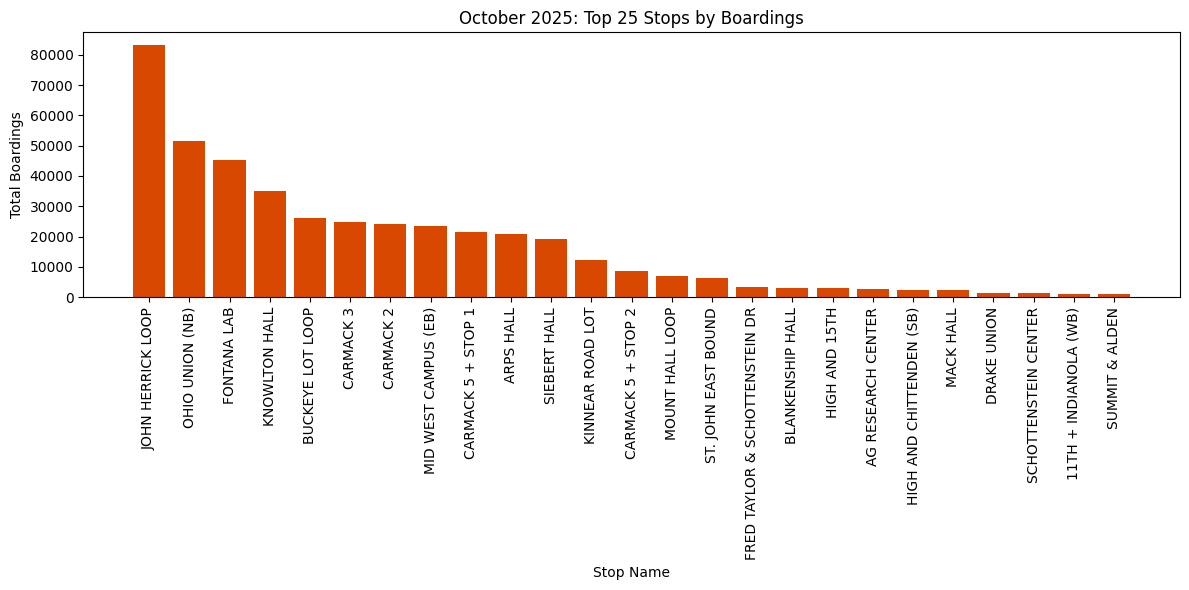

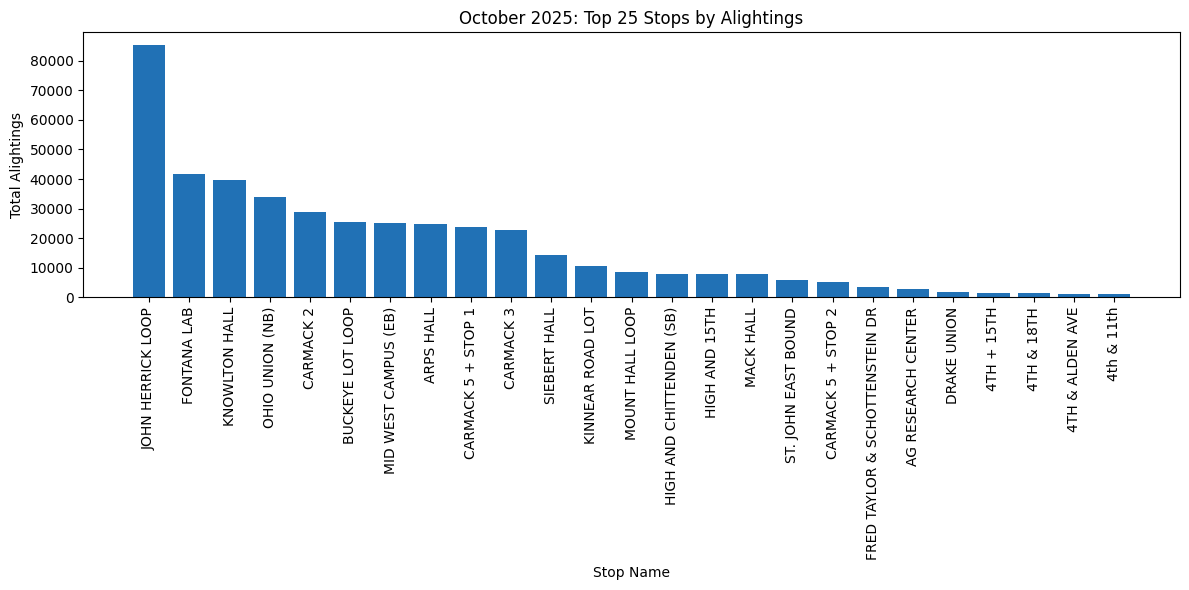

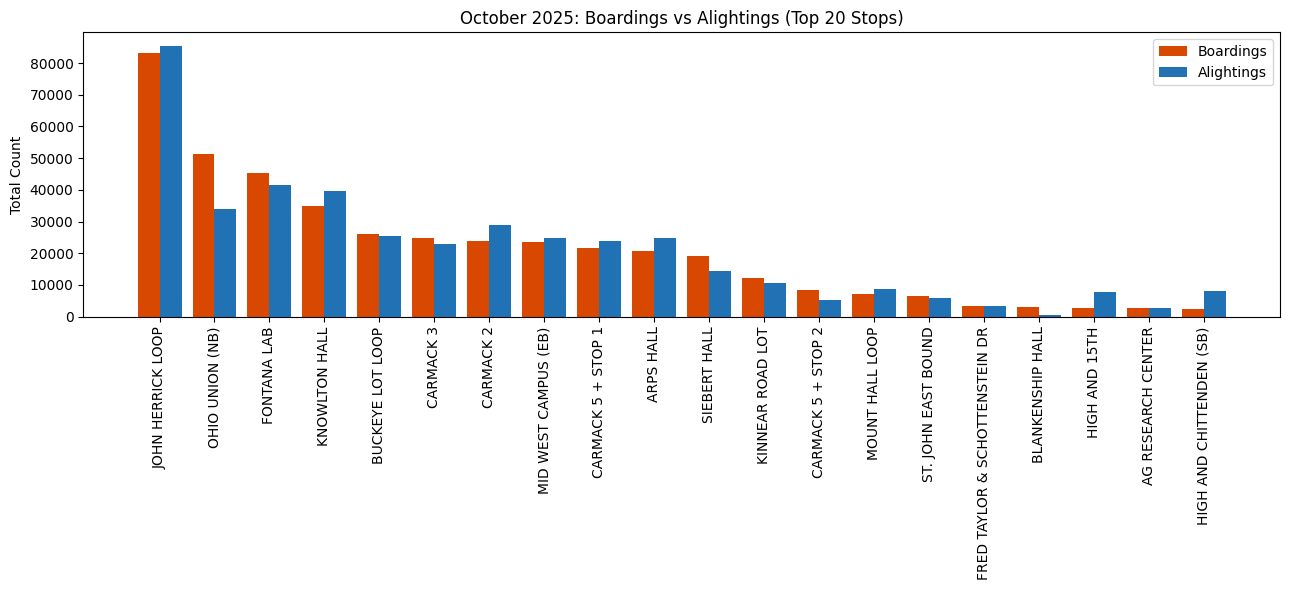

October 2025: saved 4 visualizations to \\osuad.osu.edu\files\AP\TTM\Data\transportation-planning\visualizations
--- Processing February 2026 ---
February 2026: retained 960,420 of 997,272 records


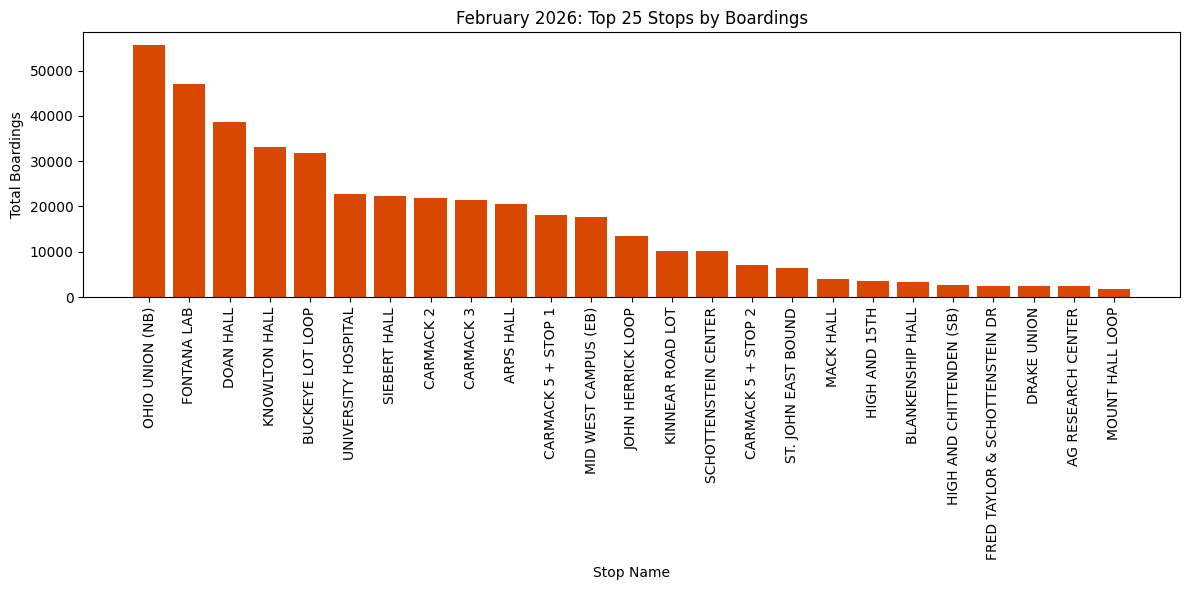

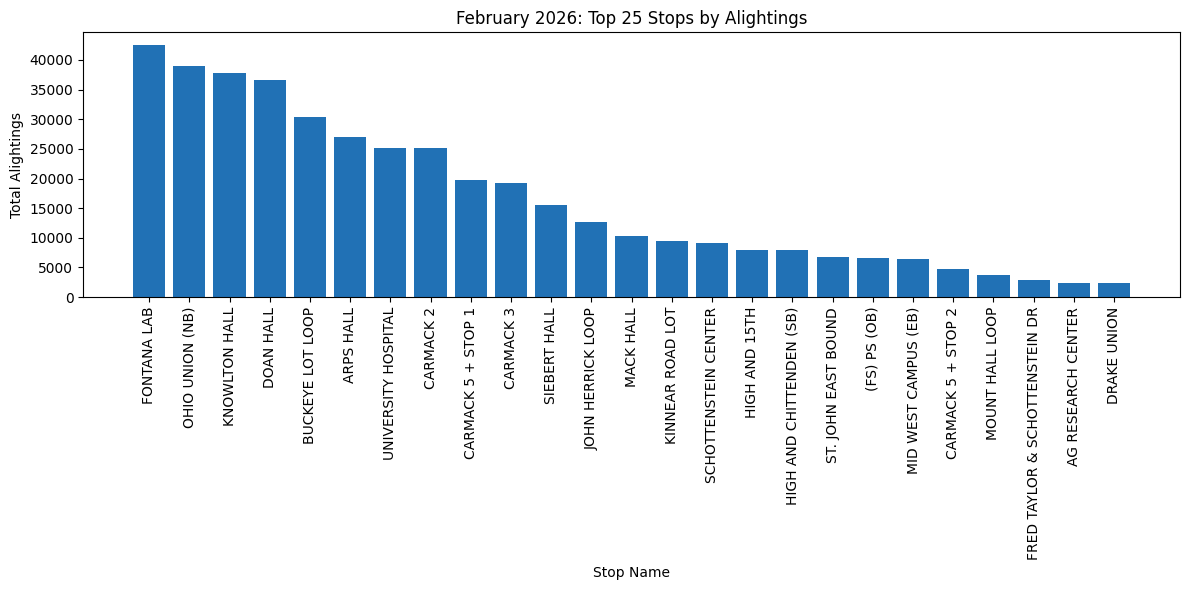

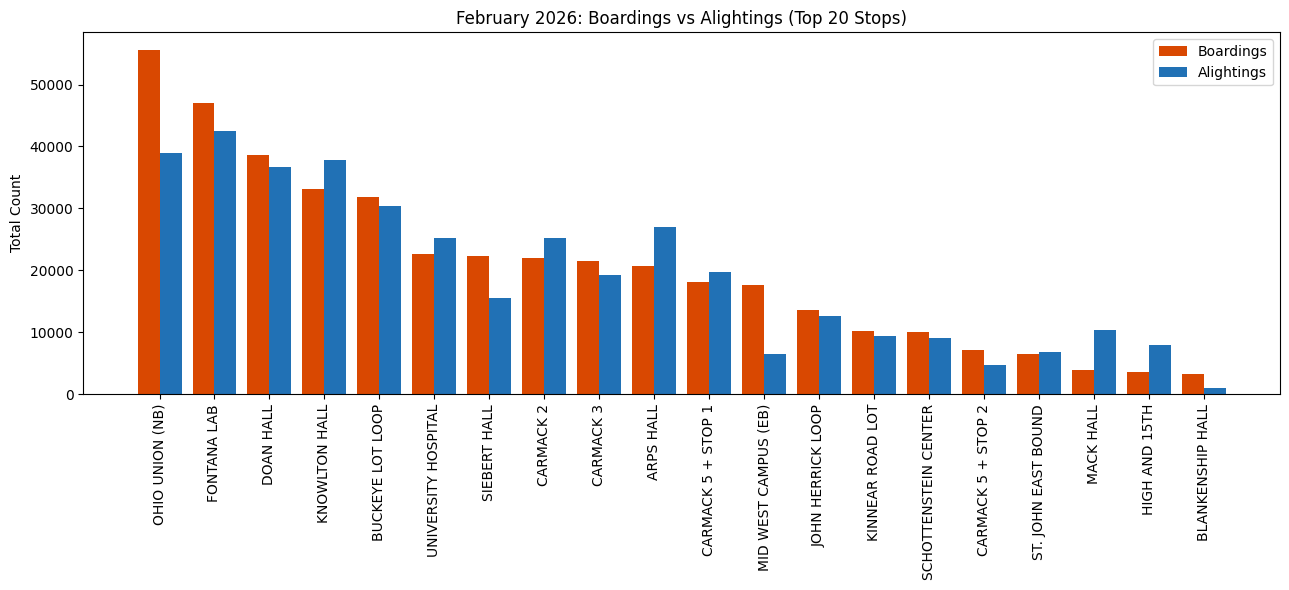

February 2026: saved 4 visualizations to \\osuad.osu.edu\files\AP\TTM\Data\transportation-planning\visualizations


In [68]:
# Configure every month to process here - add a new entry to batch-produce visualizations for more months.
month_configs = {
    'October 2025': {
        'busstate_df': busstate_dfs[0],
        'pattern_stops_path': PATTERN_STOPS_PATH + '2025082420251018Sch-PatternStops_oct2025.csv',
    },
    'February 2026': {
        'busstate_df': busstate_dfs[1],
        'pattern_stops_path': PATTERN_STOPS_PATH + '2026011220260320Sch-PatternStops_1-12-26_3-12-26.csv',
    },
}

exclude_run_ids = med_center_run_ids + [football_shuttle_id, schott_shuttle_id]

month_results = {}
for month_label, config in month_configs.items():
    month_results[month_label] = process_month(
        label=month_label,
        raw_busstate_df=config['busstate_df'],
        pattern_stops_path=config['pattern_stops_path'],
        stop_inventory_df=stop_inventory,
        exclude_run_ids=None,
        output_dir='visualizations',
        top_n=25,
    )


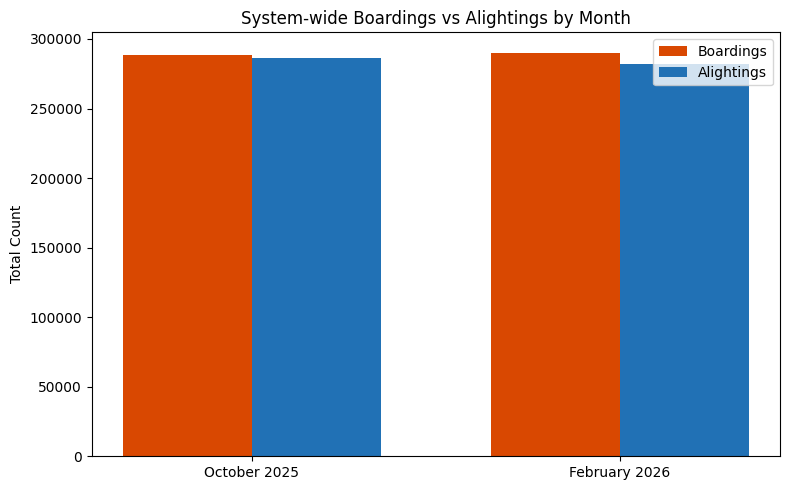

,MONTH,TOTAL_BOARDINGS,TOTAL_ALIGHTINGS
0,October 2025,288559,286151
1,February 2026,290257,281705


In [62]:
# Cross-month comparison: total system boardings/alightings per processed month.
comparison_df = pd.DataFrame([
    {
        'MONTH': month_label,
        'TOTAL_BOARDINGS': result['summary_df']['BOARDINGS_SUM'].sum(),
        'TOTAL_ALIGHTINGS': result['summary_df']['ALIGHTINGS_SUM'].sum(),
    }
    for month_label, result in month_results.items()
])

x = np.arange(len(comparison_df))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width / 2, comparison_df['TOTAL_BOARDINGS'], width, label='Boardings', color='#d94801')
ax.bar(x + width / 2, comparison_df['TOTAL_ALIGHTINGS'], width, label='Alightings', color='#2171b5')
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['MONTH'])
ax.set_ylabel('Total Count')
ax.set_title('System-wide Boardings vs Alightings by Month')
ax.legend()
fig.tight_layout()
fig.savefig('visualizations/cross_month_comparison.png', dpi=150)
plt.show()

comparison_df
